##### Linear regression to find what factors predict order value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

  STEP 6: Linear Regression
 Dataset: 95,311
 Payment Encoding:
  0 = boleto
  1 = credit_card
  2 = debit_card
  3 = voucher

    Model Performance
    ________________________________________________________
    R2 Score:         0.1565 (explains 15.7% of variation)
    Mean Abs Error: R$81.43
    RMSE:           R$125.16
    ________________________________________________________
    
  FEATURE IMPORTANCE (standardised):
  Feature                            Coef  Meaning
  --------------------------------------------------------------------
  ↑ payment_installments          53.4764  EMI users buy expensive products
  ↓ payment_encoded              -11.0262  payment method correlates with spend
  ↑ delivery_days                  7.2058  heavier items take longer to deliver
  ↓ review_score                  -2.4451  satisfied customers spend slightly more
  ↓ month_num                     -1.0236  seasonal buying patterns
  ↑ order_hour                     0.0558  minor time-of-day e

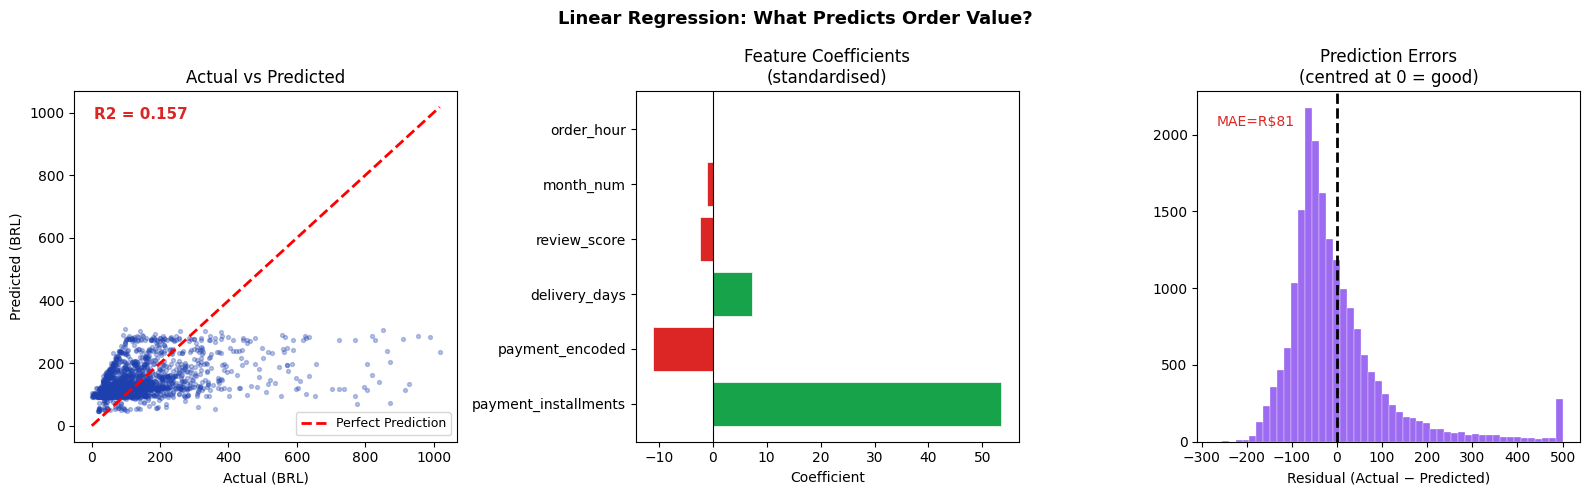


  ✅  chart9_regression.png

  BUSINESS INTERPRETATION
  ───────────────────────────────────────────────────
  1. payment_installments = strongest positive driver.
     → EMI users buy expensive products.
     → Promote 0% EMI at checkout for carts above R$200.

  2. R²=0.16 — product category explains the rest.
     → Next step: add category as feature to improve model.

  3. MAE=R$81 — average prediction error per order.
     → Acceptable baseline for a 6-variable model.
    
  ALL STEPS COMPLETE!
  Charts → data/processed/charts/


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

proc = r'C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\processed\cleaned_ecommerce_data.csv'
charts = r'C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\DA Projects\shopmart-ecommerce-analytics\data\processed\charts'

def load_data():
    return pd.read_csv(proc, parse_dates = ['order_purchase_timestamp'])

def prepare_features(df):
    """Select, encode, and clean the feature set for regression."""
    features = df[[
        'revenue',               # Target Variable
        'payment_installments',  # more EMIs = bigger purchase?
        'delivery_days',         # delivery time affect order size?
        'review_score',          # satisfied customers spend slightly more?
        'order_hour',            # time of day matters?
        'month_num',             # seasonal patterns?
        'payment_type'           # payment method effect?
    ]].dropna().copy()

    le = LabelEncoder()
    features['payment_encoded'] = le.fit_transform(features['payment_type'])

    # Cap target at P99 to remove extreme outliers
    p99 = features['revenue'].quantile(0.99)
    features = features[features['revenue'] <= p99].copy()

    print(f' Dataset: {len(features):,}')
    print(" Payment Encoding:")
    for code, label in enumerate(le.classes_):
        print(f'  {code} = {label}')
     
    return features

def train_model(features):
    """Split data, scale features, train LinearRegression, return results."""
    feat_cols = ['payment_installments', 'delivery_days', 'review_score', 
                 'order_hour','month_num', 'payment_encoded']
    X = features[feat_cols].values
    y = features['revenue'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    return model, y_test, y_pred, feat_cols

def print_results(model, y_test, y_pred, feat_cols):
    """Print R², MAE, RMSE, and coefficient interpretation."""
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))

    print(f"""
    Model Performance
    ________________________________________________________
    R2 Score:         {r2:.4f} (explains {r2*100:.1f}% of variation)
    Mean Abs Error: R${mae:.2f}
    RMSE:           R${rmse:.2f}
    ________________________________________________________
    """)

    meanings = {
        "payment_installments": "EMI users buy expensive products",
        "delivery_days":        "heavier items take longer to deliver",
        "review_score":         "satisfied customers spend slightly more",
        "order_hour":           "minor time-of-day effect on spend",
        "month_num":            "seasonal buying patterns",
        "payment_encoded":      "payment method correlates with spend",
    }

    coefs = pd.DataFrame({
        'feature': feat_cols,
        'coefficients': model.coef_
    }).sort_values('coefficients', key = abs, ascending = False)

    print("  FEATURE IMPORTANCE (standardised):")
    print(f"  {'Feature':<28} {'Coef':>10}  Meaning")
    print(f"  {'-'*68}")
    for _, row in coefs.iterrows():
        d = "↑" if row["coefficients"]>0 else "↓"
        m = meanings.get(row["feature"],"")
        print(f"  {d} {row['feature']:<26} {row['coefficients']:>10.4f}  {m}")

    return r2, mae, coefs

def save_regression_chart(y_test, y_pred, coefs, mae, r2):
    fig, axes = plt.subplots(1, 3, figsize = (16,5))
    fig.suptitle("Linear Regression: What Predicts Order Value?",
                 fontsize=13, fontweight="bold")
    # Panel 1: Actual vs Predicted scatter
    idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace = False)
    axes[0].scatter(y_test[idx], y_pred[idx],
                    alpha = 0.3, s= 8, color = '#1E40AF')
    mv = max(y_test[idx].max(), y_pred[idx].max())
    axes[0].plot([0, mv], [0, mv], 'r--', lw = 2, label = 'Perfect Prediction')
    axes[0].set_title('Actual vs Predicted')
    axes[0].set_xlabel('Actual (BRL)')
    axes[0].set_ylabel('Predicted (BRL)')
    axes[0].legend(fontsize = 9)
    axes[0].text(0.05, 0.92, f'R2 = {r2:.3f}',
                 transform = axes[0].transAxes,
                 color = '#DC2626', fontsize = 11, fontweight = 'bold')
    
    # Panel 2: Feature coefficients bar chart
    c_cols = ['#16A34A' if c>0 else '#DC2626'
              for c in coefs['coefficients']]
    axes[1].barh(coefs['feature'], coefs['coefficients'],
                 color = c_cols, edgecolor = 'white', lw = 0.5)
    axes[1].axvline(0, color = 'black', lw = 0.8)
    axes[1].set_title('Feature Coefficients\n(standardised)')
    axes[1].set_xlabel('Coefficient')

    # Panel 3: Residuals distribution (should be centred at 0)
    res = y_test - y_pred
    axes[2].hist(res.clip(-500,500), bins=50, color="#7C3AED",
                 alpha=0.75, edgecolor="white", lw=0.3)
    axes[2].axvline(0,color="black",ls="--",lw=2)
    axes[2].set_title("Prediction Errors\n(centred at 0 = good)")
    axes[2].set_xlabel("Residual (Actual − Predicted)")
    axes[2].text(0.05,0.90,f"MAE=R${mae:.0f}",
                 transform=axes[2].transAxes,
                 color="#DC2626",fontsize=10)

    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(charts,"chart9_regression.png"),
                dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("\n  ✅  chart9_regression.png")


# ── MAIN ──────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 55)
    print("  STEP 6: Linear Regression")
    print("=" * 55)

    df       = load_data()
    features = prepare_features(df)
    model, y_test, y_pred, feat_cols = train_model(features)
    r2, mae, coefs = print_results(model, y_test, y_pred, feat_cols)
    save_regression_chart(y_test, y_pred, coefs, mae, r2)

    print(f"""
  BUSINESS INTERPRETATION
  ───────────────────────────────────────────────────
  1. payment_installments = strongest positive driver.
     → EMI users buy expensive products.
     → Promote 0% EMI at checkout for carts above R$200.

  2. R²={r2:.2f} — product category explains the rest.
     → Next step: add category as feature to improve model.

  3. MAE=R${mae:.0f} — average prediction error per order.
     → Acceptable baseline for a 6-variable model.
    """)

    print("=" * 55)
    print("  ALL STEPS COMPLETE!")
    print(f"  Charts → data/processed/charts/")
    print("=" * 55)